# Classification d'images à l'aide d'algorithmes de Deep Learning

Projet n&#8239;$^\text{o}$ 6 du [cursus Machine Learning Engineer][2] d'OpenClassrooms

Auteur : [Kiril ISAKOV][1]

Mentor : Nicolas TISSERAND

Projet démarré le 23/03/2026

[1]: https://github.com/kirisakow/
[2]: https://openclassrooms.com/fr/paths/794-machine-learning-engineer

# Notebook de création et d’entraînement du modèle par *transfer learning*

## Imports et constantes

In [ ]:
DEFAULT_TRGT_IMG_SIZE = (224, 224)
DEFAULT_BATCH_SIZE = 32

import os
# Déclarer le backend avant d'importer keras (sinon par défaut c'est 'tensorflow'):
os.environ["KERAS_BACKEND"] = "torch"
# Memory optimization: Enable expandable segments to reduce fragmentation:
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
# Limiter la verbosité des logs de tensorflow:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from functions_model_building import (
    build_model_from_pretrained,
    MyKerasSequence,
    plot_accuracy_and_loss_values,
    plot_confusion_matrix,
)
import torch
import keras
# Memory optimization: Use mixed precision (if GPU supports it):
keras.mixed_precision.set_global_policy('mixed_float16')

from keras.applications.efficientnet import EfficientNetB0
from keras.applications.efficientnet_v2 import EfficientNetV2B0
from keras.applications.vgg16 import VGG16

from collections import Counter
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datetime as dt
import joblib
import itertools as it
import pytz

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
import warnings
warnings.filterwarnings("ignore")

LOGGER_FORMAT = '%(asctime)s [%(levelname)s] %(message)s'
logging.Formatter.converter = lambda *_: dt.datetime.now(pytz.timezone('Europe/Paris')).timetuple()
logging.basicConfig(level=logging.INFO, format=LOGGER_FORMAT, force=True)
logr = logging.getLogger(__name__)
logr.setLevel(logging.DEBUG)
# log_file_handler = logging.FileHandler(f"log/{dt.datetime.isoformat(dt.datetime.now(pytz.timezone('Europe/Paris'))).split('.')[0]}.log")
# log_file_handler.setLevel(logging.DEBUG)
# log_cons_handler = logging.StreamHandler()
# log_cons_handler.setLevel(logging.DEBUG)
# log_file_handler.setFormatter(logging.Formatter(fmt=LOGGER_FORMAT, style='%'))
# log_cons_handler.setFormatter(logging.Formatter(fmt=LOGGER_FORMAT, style='%'))
# logr.addHandler(log_file_handler)
# logr.addHandler(log_cons_handler)


## Étapes préliminaires : installer les pilotes GPU et tester l'installation

1. Installer ou mettre à jour le pilote pour la GPU. Par ici pour les GPU Nvidia : https://www.nvidia.com/en-us/drivers/ (spécifier le bon modèle dans le formulaire)

2. Installer le dernier CUDA toolkit (v13.2) de chez Nvidia : 

   - soit de la façon [`runfile (local)`][2] :

     ```bash
     # télécharger l'archive (taille approximative : 4,1 Go)
     wget https://developer.download.nvidia.com/compute/cuda/13.2.0/local_installers/cuda_13.2.0_595.45.04_linux.run

     # exécuter l'archive
     sudo sh cuda_13.2.0_595.45.04_linux.run
     ```

   - soit de la façon [`deb (network)`][3] :

     ```bash
     wget https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/cuda-keyring_1.1-1_all.deb
     
     sudo dpkg -i cuda-keyring_1.1-1_all.deb
     
     sudo apt update
     
     sudo apt -y install cuda-toolkit-13-2
     ```

3. Ajouter les chemins suivants aux variables d'environnement PATH et LD_LIBRARY_PATH :

     ```bash
     echo 'export PATH=/usr/local/cuda/bin:$PATH' >> ~/.bashrc
     echo 'export LD_LIBRARY_PATH=/usr/local/cuda/lib64:/usr/lib/x86_64-linux-gnu:$LD_LIBRARY_PATH' >> ~/.bashrc

     # Enfin, recharger .bashrc
     source ~/.bashrc
     ```

4. Installer le backend pour Keras (PyTorch, TensorFlow ou JAX) :

   - Pour PyTorch : Suivre [les instructions de la doc PyTorch][1] : Installer le backend `torch` and `torchvision` compatibles CUDA `>=13.0` pour les GPU Nvidia (ou ROCm `>=7.2` pour les GPU AMD).

   - Si besoin, spécifier dans `pyproject.toml` des bornes plus strictes à la version de Python : par exemple, non pas `>=3.12` mais `>=3.12,<3.14`.

5. Installer Keras : Suivre [les instructions de la doc Keras][4]

[1]: https://pytorch.org/get-started/locally/
[2]: https://developer.nvidia.com/cuda-downloads?target_os=Linux&target_arch=x86_64&Distribution=Ubuntu&target_version=24.04&target_type=runfile_local
[3]: https://developer.nvidia.com/cuda-downloads?target_os=Linux&target_arch=x86_64&Distribution=Ubuntu&target_version=24.04&target_type=deb_network
[4]: https://keras.io/getting_started/

### Tester l'installation de CUDA toolkit et de PyTorch

In [2]:
logr.debug(f"PyTorch version: {torch.__version__}")
logr.debug(f"Is CUDA available: {torch.cuda.is_available()}")
logr.debug(f"CUDA device count: {torch.cuda.device_count()}")
logr.debug(f"Current device: {torch.cuda.current_device()}")
logr.debug(f"Device name: {torch.cuda.get_device_name(0)}")

2026-05-07 12:23:41,571 [DEBUG] PyTorch version: 2.11.0+cu130
2026-05-07 12:23:41,615 [DEBUG] Is CUDA available: True
2026-05-07 12:23:41,634 [DEBUG] CUDA device count: 1
2026-05-07 12:23:41,635 [DEBUG] Current device: 0
2026-05-07 12:23:41,636 [DEBUG] Device name: NVIDIA GeForce RTX 2070 with Max-Q Design


## Entraînement du modèle de prédiction par *transfer learning*

### 1. Modèle à 3 classes et ses différentes variantes

#### 1.0. Split train - val - test (à lancer avant chaque entraînement)

In [2]:
input_img_paths = tuple([
    Path('images/n02090379-redbone'), Path('images/n02085936-Maltese_dog'), Path('images/n02088094-Afghan_hound')
])
logr.info(f"Les classes retenues : {input_img_paths}")
input_img_paths = tuple(path.glob('*.jpg') for path in input_img_paths)
input_img_paths = tuple(it.chain.from_iterable(input_img_paths))
logr.info(f"Résultat : un tuple de {len(input_img_paths)} images pour les 3 classes de races.")
breed_labels = tuple(str(path).split('/')[1] for path in input_img_paths)
breed_labels_encoded = LabelEncoder().fit_transform(breed_labels)
breed_labels_dict = dict(sorted(zip(breed_labels_encoded, breed_labels)))
logr.info(f"Distribution des classes : {dict(Counter(breed_labels))}")
display(dict(Counter(breed_labels)))
train_frac = 0.8
input_paths_train, input_paths_val_test, labels_train, labels_val_test = train_test_split(
    input_img_paths, breed_labels, train_size=train_frac,
    random_state=42, shuffle=True, stratify=breed_labels,
)
val_test_frac = 0.5
input_paths_val, input_paths_test, labels_val, labels_test = train_test_split(
    input_paths_val_test, labels_val_test, train_size=val_test_frac,
    random_state=42, shuffle=True, stratify=labels_val_test
)
del input_paths_val_test, labels_val_test
logr.info(f"Train size ({train_frac}): {len(input_paths_train)}")
logr.info(f"Val size ({round(val_test_frac * (1 - train_frac), 1)}): {len(input_paths_val)}")
logr.info(f"Test size ({round(val_test_frac * (1 - train_frac), 1)}): {len(input_paths_test)}")

2026-05-12 06:20:33,838 [INFO] Les classes retenues : (PosixPath('images/n02090379-redbone'), PosixPath('images/n02085936-Maltese_dog'), PosixPath('images/n02088094-Afghan_hound'))
2026-05-12 06:20:33,859 [INFO] Résultat : un tuple de 639 images pour les 3 classes de races.
2026-05-12 06:20:33,861 [INFO] Distribution des classes : {'n02090379-redbone': 148, 'n02085936-Maltese_dog': 252, 'n02088094-Afghan_hound': 239}


{'n02090379-redbone': 148,
 'n02085936-Maltese_dog': 252,
 'n02088094-Afghan_hound': 239}

2026-05-12 06:20:33,867 [INFO] Train size (0.8): 511
2026-05-12 06:20:33,867 [INFO] Val size (0.1): 64
2026-05-12 06:20:33,868 [INFO] Test size (0.1): 64


#### 1.a) Entraînement à 3 classes sur la base du modèle pré-entraîné `EfficientNetB0`

In [3]:
PRTR_MDL = EfficientNetB0
PREPROCESSING_FUNC = keras.applications.efficientnet.preprocess_input
train_seq = MyKerasSequence(input_paths_train, labels_train, DEFAULT_BATCH_SIZE, DEFAULT_TRGT_IMG_SIZE, PREPROCESSING_FUNC)
val_seq = MyKerasSequence(input_paths_val, labels_val, DEFAULT_BATCH_SIZE, DEFAULT_TRGT_IMG_SIZE, PREPROCESSING_FUNC)
test_seq = MyKerasSequence(input_paths_test, labels_test, DEFAULT_BATCH_SIZE, DEFAULT_TRGT_IMG_SIZE, PREPROCESSING_FUNC)
N_CLASSES = 3
N_EPOCHS = 20
DROPOUT_RATE = 0.2
LR = 1e-5  # learning rate doit être faible !
experiment_name = f'CNN__from={PRTR_MDL.__name__}__n_cls={N_CLASSES}__n_eps={N_EPOCHS}__drpt={DROPOUT_RATE:.2f}__LR={LR}'

Construire le modèle :

In [4]:
model = build_model_from_pretrained(
    pretrained_model=PRTR_MDL,
    n_classes=N_CLASSES,
    target_img_size=DEFAULT_TRGT_IMG_SIZE,
    dropout_rate=DROPOUT_RATE,
    experiment_name=experiment_name
)
model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
display(
    # model.summary(),
    # keras.utils.plot_model(model, show_shapes=True, dpi=64),
)

Entraînement et validation :

In [5]:
torch.cuda.empty_cache()

2026-05-12 05:54:20,705 [INFO] Entraînement du modèle 'CNN__from=EfficientNetB0__n_cls=3__n_eps=20__drpt=0.20__LR=1e-05'...
W0000 00:00:1778558062.447495 3322285 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-05-12 05:55:48,317 [INFO] Entraînement du modèle 'CNN__from=EfficientNetB0__n_cls=3__n_eps=20__drpt=0.20__LR=1e-05' terminé
2026-05-12 05:55:48,317 [INFO] Sauvegarder l'objet 'models/from_pretrained/CNN__from=EfficientNetB0__n_cls=3__n_eps=20__drpt=0.20__LR=1e-05_model.keras'
2026-05-12 05:55:48,711 [INFO] Sauvegarder l'objet 'models/from_pretrained/CNN__from=EfficientNetB0__n_cls=3__n_eps=20__drpt=0.20__LR=1e-05_history.joblib'


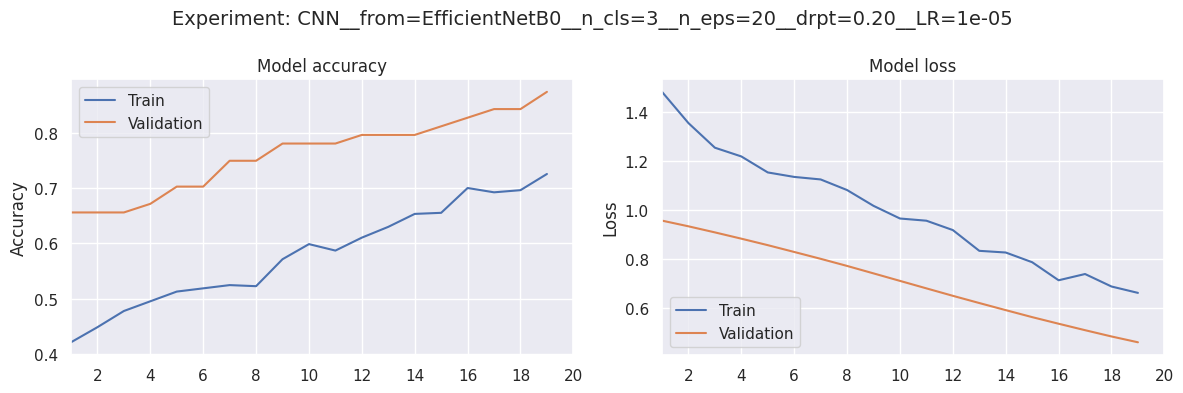

2026-05-12 05:55:49,424 [INFO] Précision finale de l'entraînement: 0.7260
2026-05-12 05:55:49,431 [INFO] Précision finale de la validation: 0.8750
2026-05-12 05:55:49,431 [INFO] Loss finale de l'entraînement: 0.6626
2026-05-12 05:55:49,432 [INFO] Loss finale de la validation: 0.4609


In [6]:
path_to_model = f'models/from_pretrained/{experiment_name}_model.keras'
path_to_history = f'models/from_pretrained/{experiment_name}_history.joblib'
if os.path.exists(path_to_model) and os.path.exists(path_to_history):
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_model!r}")
    model = keras.saving.load_model(path_to_model)
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_history!r}")
    history = joblib.load(path_to_history)
else:
    logr.info(f"Entraînement du modèle {experiment_name!r}...")
    callbacks = [keras.callbacks.TensorBoard(log_dir=f"log/{experiment_name}")]
    history = model.fit(train_seq, validation_data=val_seq, epochs=N_EPOCHS, callbacks=callbacks, verbose=0)
    logr.info(f"Entraînement du modèle {experiment_name!r} terminé")
    logr.info(f"Sauvegarder l'objet {path_to_model!r}")
    keras.saving.save_model(model, path_to_model, overwrite=True)
    logr.info(f"Sauvegarder l'objet {path_to_history!r}")
    joblib.dump(history, path_to_history)
# Tracer la précision et la loss du training & de la validation
plot_accuracy_and_loss_values(history, suptitle=f'Experiment: {experiment_name}', legend_location={'accuracy': 'upper left', 'loss': 'lower left'})
logr.info(f"Précision finale de l'entraînement: {history.history['accuracy'][-1]:.4f}")
logr.info(f"Précision finale de la validation: {history.history['val_accuracy'][-1]:.4f}")
logr.info(f"Loss finale de l'entraînement: {history.history['loss'][-1]:.4f}")
logr.info(f"Loss finale de la validation: {history.history['val_loss'][-1]:.4f}")

Évaluation sur les données de test :

2026-05-12 05:55:49,441 [INFO] Évaluation sur les données de test :


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.7969 - loss: 0.5544


2026-05-12 05:55:49,898 [INFO] loss, accuracy = [0.5543910264968872, 0.796875]


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step


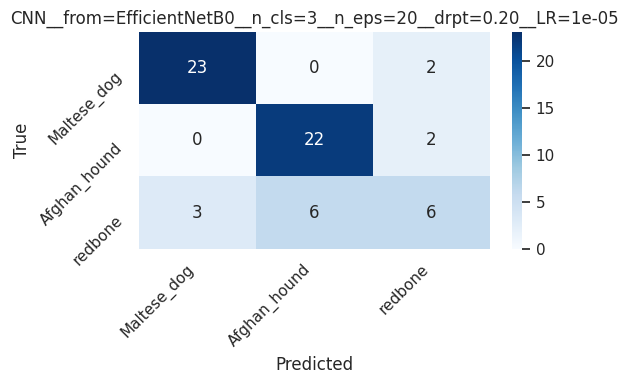

In [7]:
logr.info(f"Évaluation sur les données de test :")
logr.info(f"loss, accuracy = {model.evaluate(test_seq)}")
plot_confusion_matrix(model, test_seq, test_seq.yset, breed_labels_dict.values(), title=f'{experiment_name}')

#### 1.b) Entraînement à 3 classes sur la base du modèle pré-entraîné `EfficientNetV2B0`

In [3]:
PRTR_MDL = EfficientNetV2B0
PREPROCESSING_FUNC = keras.applications.efficientnet_v2.preprocess_input
train_seq = MyKerasSequence(input_paths_train, labels_train, DEFAULT_BATCH_SIZE, DEFAULT_TRGT_IMG_SIZE, PREPROCESSING_FUNC)
val_seq = MyKerasSequence(input_paths_val, labels_val, DEFAULT_BATCH_SIZE, DEFAULT_TRGT_IMG_SIZE, PREPROCESSING_FUNC)
test_seq = MyKerasSequence(input_paths_test, labels_test, DEFAULT_BATCH_SIZE, DEFAULT_TRGT_IMG_SIZE, PREPROCESSING_FUNC)
N_CLASSES = 3
N_EPOCHS = 20
DROPOUT_RATE = 0.2
LR = 1e-5  # learning rate doit être faible !
experiment_name = f'CNN__from={PRTR_MDL.__name__}__n_cls={N_CLASSES}__n_eps={N_EPOCHS}__drpt={DROPOUT_RATE:.2f}__LR={LR}'

Construire le modèle :

In [4]:
model = build_model_from_pretrained(
    pretrained_model=PRTR_MDL,
    n_classes=N_CLASSES,
    target_img_size=DEFAULT_TRGT_IMG_SIZE,
    dropout_rate=DROPOUT_RATE,
    experiment_name=experiment_name
)
model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
display(
    # model.summary(),
    # keras.utils.plot_model(model, show_shapes=True, dpi=64),
)

Entraînement et validation :

In [5]:
torch.cuda.empty_cache()

2026-05-12 05:56:41,811 [INFO] Entraînement du modèle 'CNN__from=EfficientNetV2B0__n_cls=3__n_eps=20__drpt=0.20__LR=1e-05'...
W0000 00:00:1778558203.643882 3330351 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-05-12 05:58:12,858 [INFO] Entraînement du modèle 'CNN__from=EfficientNetV2B0__n_cls=3__n_eps=20__drpt=0.20__LR=1e-05' terminé
2026-05-12 05:58:12,858 [INFO] Sauvegarder l'objet 'models/from_pretrained/CNN__from=EfficientNetV2B0__n_cls=3__n_eps=20__drpt=0.20__LR=1e-05_model.keras'
2026-05-12 05:58:13,356 [INFO] Sauvegarder l'objet 'models/from_pretrained/CNN__from=EfficientNetV2B0__n_cls=3__n_eps=20__drpt=0.20__LR=1e-05_history.joblib'


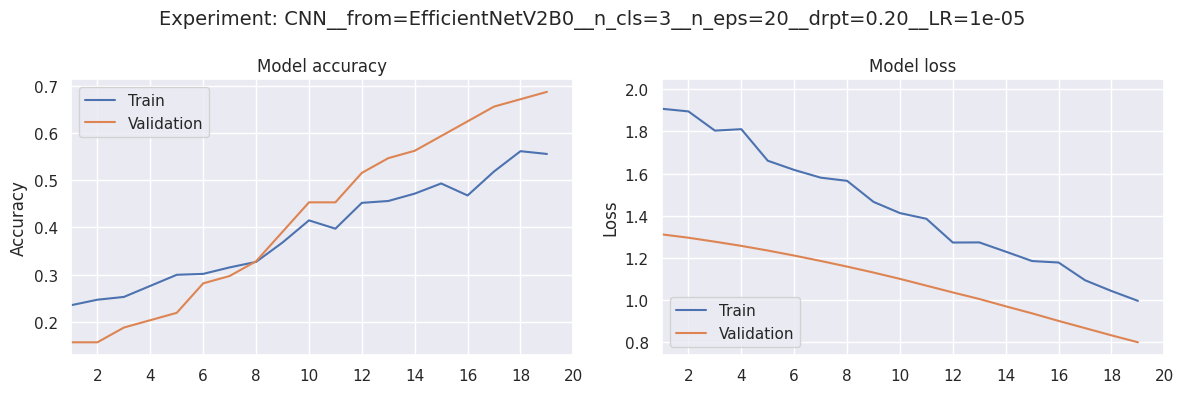

2026-05-12 05:58:14,121 [INFO] Précision finale de l'entraînement: 0.5558
2026-05-12 05:58:14,134 [INFO] Précision finale de la validation: 0.6875
2026-05-12 05:58:14,134 [INFO] Loss finale de l'entraînement: 0.9950
2026-05-12 05:58:14,135 [INFO] Loss finale de la validation: 0.7982


In [6]:
path_to_model = f'models/from_pretrained/{experiment_name}_model.keras'
path_to_history = f'models/from_pretrained/{experiment_name}_history.joblib'
if os.path.exists(path_to_model) and os.path.exists(path_to_history):
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_model!r}")
    model = keras.saving.load_model(path_to_model)
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_history!r}")
    history = joblib.load(path_to_history)
else:
    logr.info(f"Entraînement du modèle {experiment_name!r}...")
    callbacks = [keras.callbacks.TensorBoard(log_dir=f"log/{experiment_name}")]
    history = model.fit(train_seq, validation_data=val_seq, epochs=N_EPOCHS, callbacks=callbacks, verbose=0)
    logr.info(f"Entraînement du modèle {experiment_name!r} terminé")
    logr.info(f"Sauvegarder l'objet {path_to_model!r}")
    keras.saving.save_model(model, path_to_model, overwrite=True)
    logr.info(f"Sauvegarder l'objet {path_to_history!r}")
    joblib.dump(history, path_to_history)
# Tracer la précision et la loss du training & de la validation
plot_accuracy_and_loss_values(history, suptitle=f'Experiment: {experiment_name}', legend_location={'accuracy': 'upper left', 'loss': 'lower left'})
logr.info(f"Précision finale de l'entraînement: {history.history['accuracy'][-1]:.4f}")
logr.info(f"Précision finale de la validation: {history.history['val_accuracy'][-1]:.4f}")
logr.info(f"Loss finale de l'entraînement: {history.history['loss'][-1]:.4f}")
logr.info(f"Loss finale de la validation: {history.history['val_loss'][-1]:.4f}")

Évaluation sur les données de test :

2026-05-12 05:58:14,143 [INFO] Évaluation sur les données de test :


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.7031 - loss: 0.8431


2026-05-12 05:58:14,622 [INFO] loss, accuracy = [0.8430703282356262, 0.703125]


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 375ms/step


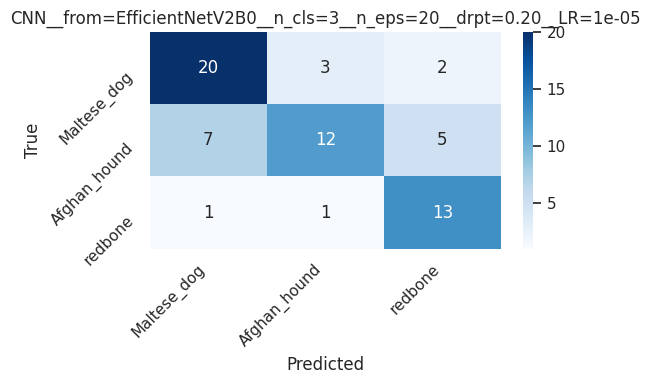

In [7]:
logr.info(f"Évaluation sur les données de test :")
logr.info(f"loss, accuracy = {model.evaluate(test_seq)}")
plot_confusion_matrix(model, test_seq, test_seq.yset, breed_labels_dict.values(), title=f'{experiment_name}')

#### 1.c) Entraînement à 3 classes sur la base du modèle pré-entraîné `VGG16`

In [3]:
PRTR_MDL = VGG16
PREPROCESSING_FUNC = keras.applications.vgg16.preprocess_input
train_seq = MyKerasSequence(input_paths_train, labels_train, DEFAULT_BATCH_SIZE, DEFAULT_TRGT_IMG_SIZE, PREPROCESSING_FUNC)
val_seq = MyKerasSequence(input_paths_val, labels_val, DEFAULT_BATCH_SIZE, DEFAULT_TRGT_IMG_SIZE, PREPROCESSING_FUNC)
test_seq = MyKerasSequence(input_paths_test, labels_test, DEFAULT_BATCH_SIZE, DEFAULT_TRGT_IMG_SIZE, PREPROCESSING_FUNC)
N_CLASSES = 3
N_EPOCHS = 20
DROPOUT_RATE = 0.2
LR = 1e-5  # learning rate doit être faible !
experiment_name = f'CNN__from={PRTR_MDL.__name__}__n_cls={N_CLASSES}__n_eps={N_EPOCHS}__drpt={DROPOUT_RATE:.2f}__LR={LR}'

Construire le modèle :

In [4]:
model = build_model_from_pretrained(
    pretrained_model=PRTR_MDL,
    n_classes=N_CLASSES,
    target_img_size=DEFAULT_TRGT_IMG_SIZE,
    dropout_rate=DROPOUT_RATE,
    experiment_name=experiment_name
)
model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
display(
    # model.summary(),
    # keras.utils.plot_model(model, show_shapes=True, dpi=64),
)

Entraînement et validation :

In [5]:
torch.cuda.empty_cache()

2026-05-12 06:20:37,694 [INFO] Entraînement du modèle 'CNN__from=VGG16__n_cls=3__n_eps=20__drpt=0.20__LR=1e-05'...
W0000 00:00:1778559639.587333 3413741 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-05-12 06:21:44,331 [INFO] Entraînement du modèle 'CNN__from=VGG16__n_cls=3__n_eps=20__drpt=0.20__LR=1e-05' terminé
2026-05-12 06:21:44,332 [INFO] Sauvegarder l'objet 'models/from_pretrained/CNN__from=VGG16__n_cls=3__n_eps=20__drpt=0.20__LR=1e-05_model.keras'
2026-05-12 06:21:44,498 [INFO] Sauvegarder l'objet 'models/from_pretrained/CNN__from=VGG16__n_cls=3__n_eps=20__drpt=0.20__LR=1e-05_history.joblib'


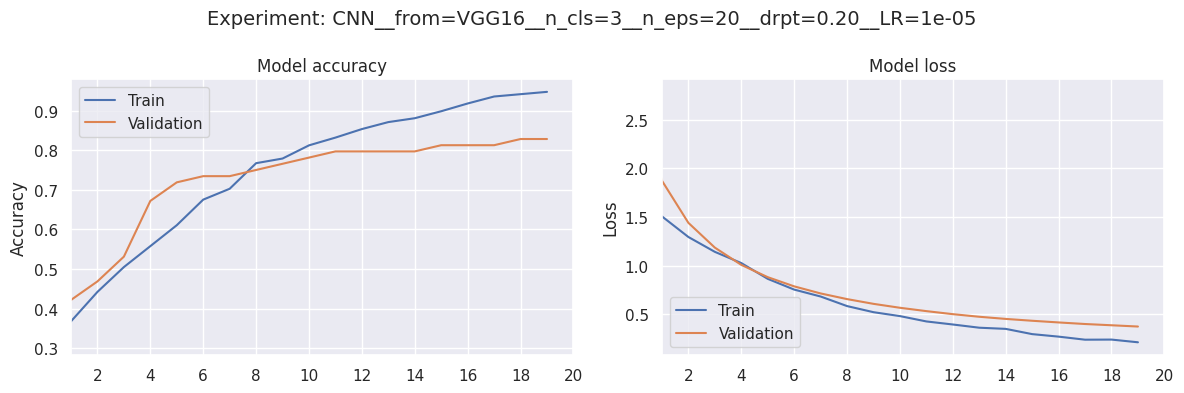

2026-05-12 06:21:45,023 [INFO] Précision finale de l'entraînement: 0.9472
2026-05-12 06:21:45,030 [INFO] Précision finale de la validation: 0.8281
2026-05-12 06:21:45,031 [INFO] Loss finale de l'entraînement: 0.2110
2026-05-12 06:21:45,031 [INFO] Loss finale de la validation: 0.3730


In [6]:
path_to_model = f'models/from_pretrained/{experiment_name}_model.keras'
path_to_history = f'models/from_pretrained/{experiment_name}_history.joblib'
if os.path.exists(path_to_model) and os.path.exists(path_to_history):
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_model!r}")
    model = keras.saving.load_model(path_to_model)
    logr.info(f"Désérialiser l'objet sauvegardé {path_to_history!r}")
    history = joblib.load(path_to_history)
else:
    logr.info(f"Entraînement du modèle {experiment_name!r}...")
    callbacks = [keras.callbacks.TensorBoard(log_dir=f"log/{experiment_name}")]
    history = model.fit(train_seq, validation_data=val_seq, epochs=N_EPOCHS, callbacks=callbacks, verbose=0)
    logr.info(f"Entraînement du modèle {experiment_name!r} terminé")
    logr.info(f"Sauvegarder l'objet {path_to_model!r}")
    keras.saving.save_model(model, path_to_model, overwrite=True)
    logr.info(f"Sauvegarder l'objet {path_to_history!r}")
    joblib.dump(history, path_to_history)
# Tracer la précision et la loss du training & de la validation
plot_accuracy_and_loss_values(history, suptitle=f'Experiment: {experiment_name}', legend_location={'accuracy': 'upper left', 'loss': 'lower left'})
logr.info(f"Précision finale de l'entraînement: {history.history['accuracy'][-1]:.4f}")
logr.info(f"Précision finale de la validation: {history.history['val_accuracy'][-1]:.4f}")
logr.info(f"Loss finale de l'entraînement: {history.history['loss'][-1]:.4f}")
logr.info(f"Loss finale de la validation: {history.history['val_loss'][-1]:.4f}")

Évaluation sur les données de test :

2026-05-12 06:21:45,039 [INFO] Évaluation sur les données de test :


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9062 - loss: 0.3776


2026-05-12 06:21:45,418 [INFO] loss, accuracy = [0.3776032030582428, 0.90625]


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


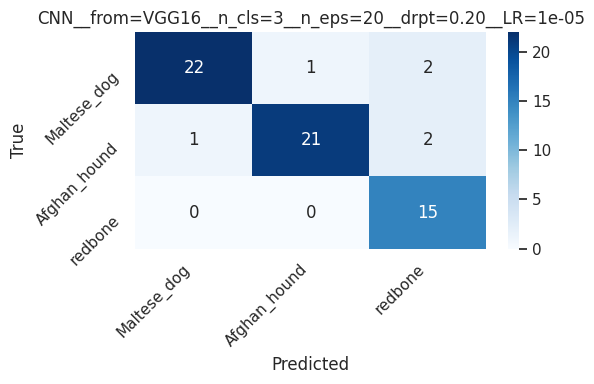

In [7]:
logr.info(f"Évaluation sur les données de test :")
logr.info(f"loss, accuracy = {model.evaluate(test_seq)}")
plot_confusion_matrix(model, test_seq, test_seq.yset, breed_labels_dict.values(), title=f'{experiment_name}')